In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow nltk wordcloud contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import contractions

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense
)

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# unzipping
import zipfile
import os

zip_path = "/content/drive/MyDrive/college/sem6/AI&ML/Workshops/Workshop9/tweet_dataset_sentiment_analysis.zip"
extract_path = "/content/tweet_dataset"

# Create extraction folder
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)
print(os.listdir(extract_path))

Files extracted to: /content/tweet_dataset
['database.sqlite', 'Tweets.csv']


In [ ]:
df = pd.read_csv("/content/tweet_dataset/Tweets.csv")


In [ ]:
df = df[['text', 'airline_sentiment']]

In [ ]:
print(df.head())

                                                text airline_sentiment
0                @VirginAmerica What @dhepburn said.           neutral
1  @VirginAmerica plus you've added commercials t...          positive
2  @VirginAmerica I didn't today... Must mean I n...           neutral
3  @VirginAmerica it's really aggressive to blast...          negative
4  @VirginAmerica and it's a really big bad thing...          negative


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   text               14640 non-null  object
 1   airline_sentiment  14640 non-null  object
dtypes: object(2)
memory usage: 228.9+ KB


In [ ]:
df['airline_sentiment'].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


In [ ]:
df['airline_sentiment'].value_counts(normalize=True) * 100

,proportion
airline_sentiment,
negative,62.691257
neutral,21.168033
positive,16.140710


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5356015914391549), 1: np.float64(2.0504201680672267), 2: np.float64(1.5498213576816198)}


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    words = text.split()

    # Remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
df['cleaned_text'] = df['text'].apply(clean_text)

print(df[['text', 'cleaned_text']].head())

                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                        cleaned_text  
0                                               said  
1             plus added commercial experience tacky  
2             today must mean need take another trip  
3  really aggressive blast obnoxious entertainmen...  
4                               really big bad thing  


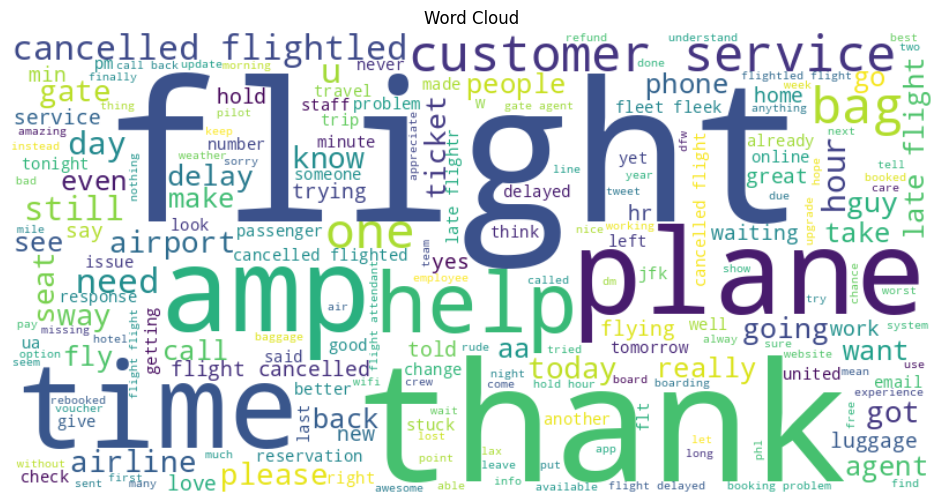

In [ ]:
all_words = " ".join(df['cleaned_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

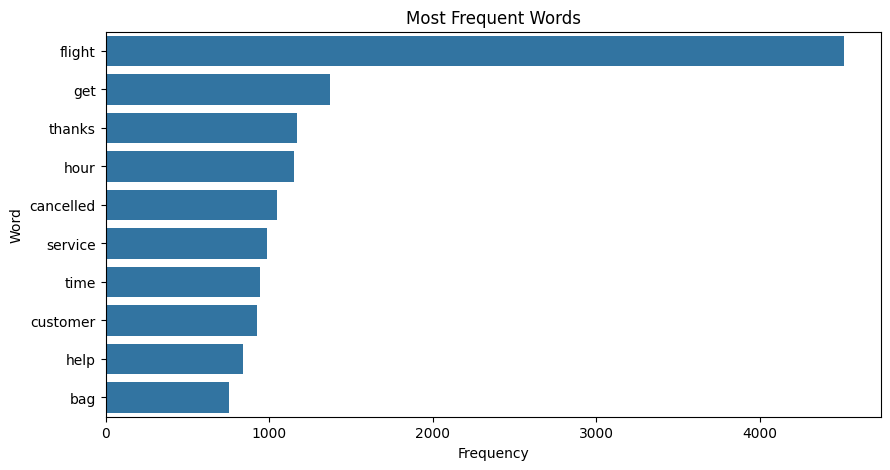

In [ ]:
from collections import Counter

words = all_words.split()

word_freq = Counter(words)

common_words = word_freq.most_common(10)

words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(10,5))
sns.barplot(
    x='Frequency',
    y='Word',
    data=words_df
)

plt.title("Most Frequent Words")
plt.show()

In [ ]:
df.head()

,text,airline_sentiment,cleaned_text
0,@VirginAmerica What @dhepburn said.,neutral,said
1,@VirginAmerica plus you've added commercials t...,positive,plus added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,neutral,today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,negative,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,negative,really big bad thing


In [ ]:
df['airline_sentiment'].unique()

array(['neutral', 'positive', 'negative'], dtype=object)

In [ ]:
X = df['cleaned_text']
y = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(X_train)

In [ ]:
import pickle

In [ ]:
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
sequence_lengths = [len(seq) for seq in X_train_seq]

max_length = int(np.percentile(sequence_lengths, 95))

print("Max Length:", max_length)

Max Length: 14


In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

In [ ]:
label_map = {
    "negative": 0,
    "positive": 1,
    "neutral": 2
}

# Encode train labels
y_train = y_train.map(label_map)

# Encode test labels
y_test = y_test.map(label_map)

# Convert to numpy arrays
y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

# Ensure padded sequences are int32
X_train_pad = np.array(X_train_pad, dtype=np.int32)
X_test_pad = np.array(X_test_pad, dtype=np.int32)

In [ ]:
rnn_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    SimpleRNN(64),

    Dense(3, activation='softmax')
])

In [ ]:
import numpy as np

X_train_pad = np.array(X_train_pad, dtype=np.int32)
y_train = np.array(y_train, dtype=np.int32)

In [ ]:
rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,547 (4.93 MB)

 Trainable params: 1,292,547 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stop],
    batch_size=32,
    class_weight = class_weights
)

Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9731 - loss: 0.0888 - val_accuracy: 0.6936 - val_loss: 1.1022
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9773 - loss: 0.0744 - val_accuracy: 0.6957 - val_loss: 1.1796
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9842 - loss: 0.0556 - val_accuracy: 0.6816 - val_loss: 1.2624
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9858 - loss: 0.0523 - val_accuracy: 0.6586 - val_loss: 1.3744
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9873 - loss: 0.0480 - val_accuracy: 0.6974 - val_loss: 1.3062
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9888 - loss: 0.0444 - val_accuracy: 0.7162 - val_loss: 1.3316


In [ ]:
print(X_train_pad.dtype)
print(y_train.dtype)

int32
int32


In [ ]:
rnn_pred_probs = rnn_model.predict(X_test_pad)

rnn_pred = np.argmax(rnn_pred_probs, axis=1)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
rnn_acc = accuracy_score(y_test, rnn_pred)

print("RNN Accuracy:", rnn_acc)

RNN Accuracy: 0.7069672131147541


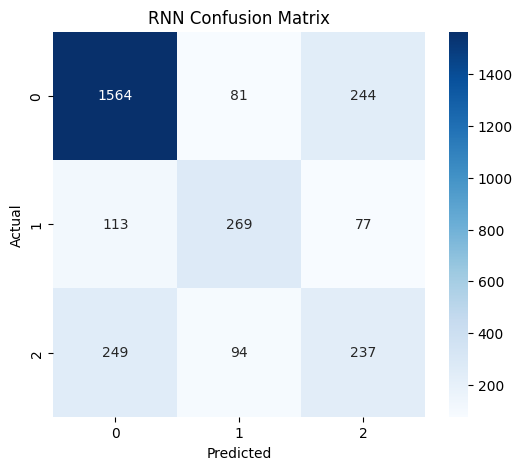

In [ ]:
cm = confusion_matrix(y_test, rnn_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("RNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
checkpoint = ModelCheckpoint(
    filepath='best_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    verbose=1
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(64, dropout=0.2, recurrent_dropout=0.2)
    ),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6523 - loss: 0.7974
Epoch 1: val_loss improved from None to 0.55451, saving model to best_lstm_model.h5



Epoch 1: finished saving model to best_lstm_model.h5
293/293 ━━━━━━━━━━━━━━━━━━━━ 53s 143ms/step - accuracy: 0.7128 - loss: 0.6798 - val_accuracy: 0.7781 - val_loss: 0.5545 - learning_rate: 0.0010
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8398 - loss: 0.4156
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 2: val_loss did not improve from 0.55451
293/293 ━━━━━━━━━━━━━━━━━━━━ 41s 141ms/step - accuracy: 0.8373 - loss: 0.4204 - val_accuracy: 0.7764 - val_loss: 0.5855 - learning_rate: 0.0010
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9081 - loss: 0.2674
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 3: val_loss did not improve from 0.55451
293/293 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/step - accuracy: 0.9076 - loss: 0.2642 - val_accuracy: 0.7627 - val_loss: 0.6856 - learning_rate: 5.0000e-04


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import numpy as np

# Predict probabilities
pred_probs = lstm_model.predict(X_test_pad)

# Convert probabilities to class labels
pred = np.argmax(pred_probs, axis=1)

# Accuracy
acc = accuracy_score(y_test, pred)

print("LSTM Accuracy:", acc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    pred,
    target_names=["neutral", "positive", "negative"]
))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred))

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
LSTM Accuracy: 0.7862021857923497

Classification Report:

              precision    recall  f1-score   support

     neutral       0.83      0.91      0.87      1889
    positive       0.73      0.68      0.70       459
    negative       0.64      0.46      0.53       580

    accuracy                           0.79      2928
   macro avg       0.73      0.68      0.70      2928
weighted avg       0.77      0.79      0.78      2928


Confusion Matrix:

[[1727   58  104]
 [ 106  310   43]
 [ 258   57  265]]


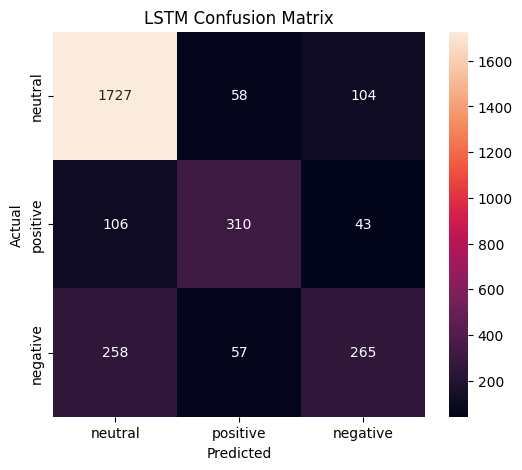

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=["neutral", "positive", "negative"],
    yticklabels=["neutral", "positive", "negative"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")

plt.show()

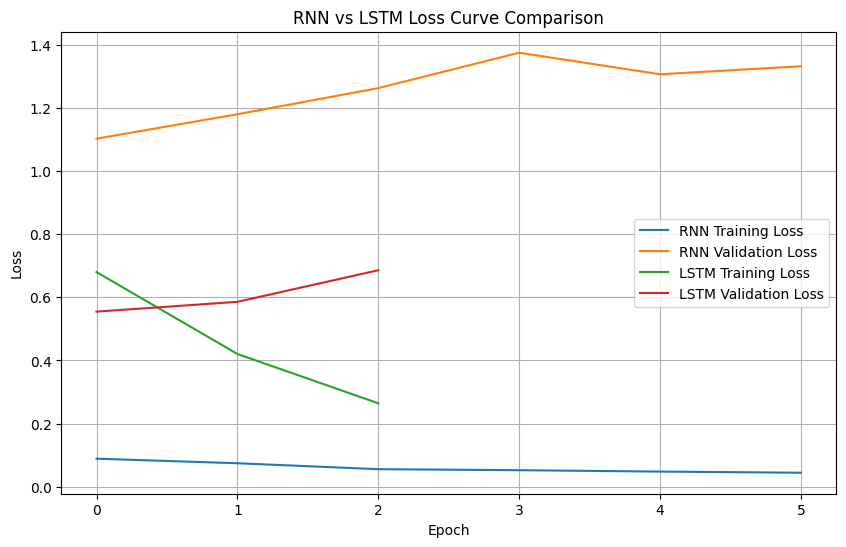

In [ ]:
import matplotlib.pyplot as plt

# Plot Training & Validation Loss
plt.figure(figsize=(10,6))

# RNN Loss
plt.plot(
    rnn_history.history['loss'],
    label='RNN Training Loss'
)

plt.plot(
    rnn_history.history['val_loss'],
    label='RNN Validation Loss'
)

# LSTM Loss
plt.plot(
    lstm_history.history['loss'],
    label='LSTM Training Loss'
)

plt.plot(
    lstm_history.history['val_loss'],
    label='LSTM Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN vs LSTM Loss Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()